# 01 - Write the Finding (v1 sweep analysis)

Analysis notebook for the v1 sweep (107/107 cells, 0 failures). Numbers and
figures here feed the paper Results section once the xvla re-run lands.

Data sources (read top-to-bottom):

1. `results/sweep-full/results.parquet` - base sweep, 5250 rows.
2. `results/sweep-full/results-act-rerun.parquet` - corrects `act x aloha_transfer_cube`.
3. `results/sweep-full/results-xvla-rerun.parquet` - corrects `xvla_libero x libero_*`
   (does not exist yet; helper is a no-op when missing).

Re-runs are layered on top of the base parquet via the `load_results_with_reruns`
helper in cell 2 - on `(policy, env, seed, episode_index)` key. Re-derivation:
re-run the whole notebook against the merged sweep dir.

Stats helpers come from `lerobot_bench.stats`. Bootstrap CIs are pivotal
(`bootstrap_pivotal_ci`), point estimates use Wilson scoring (`wilson_ci`).
Deterministic seed = 42 everywhere a bootstrap is invoked.

Outline:

1. Imports + repo wiring.
2. Load helper + load merged frame.
3. Schema + sanity (RESULT_SCHEMA, episode count contract, null guard).
4. Provenance map - which rows came from which file.
5. Per-policy headline (leaderboard).
6. Per-(policy, env) breakdown with provenance glyphs.
7. smolvla LIBERO bar chart vs paper-reported.
8. diffusion_policy x pusht single stat.
9. Baseline sanity (no_op, random).
10. Anomaly callout (cells < 50% of paper-reported).
11. Stats-rigor block (Wilson vs bootstrap reconciliation + seed variance).
12. Reproducibility footer.

In [1]:
# Cell 1 - Imports + repo wiring
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Resolve repo root from notebook CWD (notebooks/ sits at repo root).
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src' / 'lerobot_bench').is_dir() and (REPO_ROOT.parent / 'src' / 'lerobot_bench').is_dir():
    REPO_ROOT = REPO_ROOT.parent
src_path = str(REPO_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import lerobot_bench
from lerobot_bench.checkpointing import RESULT_SCHEMA
from lerobot_bench.stats import (
    bootstrap_pivotal_ci,
    wilson_ci,
    wilson_halfwidth_at_p,
)

# Path constants. `env_dashboard_results_dir` lives in dashboard/_helpers.py
# which is a dashboard concern; hardcode the sweep dir here per task brief.
SWEEP_DIR = REPO_ROOT / 'results' / 'sweep-full'
BASE_PARQUET = SWEEP_DIR / 'results.parquet'
ACT_RERUN_PARQUET = SWEEP_DIR / 'results-act-rerun.parquet'
XVLA_RERUN_PARQUET = SWEEP_DIR / 'results-xvla-rerun.parquet'
POLICIES_YAML = REPO_ROOT / 'configs' / 'policies.yaml'

# Locked bootstrap settings (matches docs/DESIGN.md methodology).
N_RESAMPLES = 10_000
BOOTSTRAP_SEED = 42
CI = 0.95
ALPHA = 1.0 - CI

print(f'lerobot_bench version    : {lerobot_bench.__version__}')
print(f'sweep dir                : {SWEEP_DIR}')
print(f'base parquet exists      : {BASE_PARQUET.exists()}')
print(f'act rerun parquet exists : {ACT_RERUN_PARQUET.exists()}')
print(f'xvla rerun parquet exists: {XVLA_RERUN_PARQUET.exists()}')

lerobot_bench version    : 0.0.1
sweep dir                : results/sweep-full
base parquet exists      : True
act rerun parquet exists : True
xvla rerun parquet exists: False


In [2]:
# Cell 2 - load_results_with_reruns helper + load merged frame
#
# Re-runs are overlays: every (policy, env, seed, episode_index) key present
# in any rerun parquet replaces the matching base row. The helper records
# the source file each row came from so cell 4 can annotate provenance.

KEY_COLS = ('policy', 'env', 'seed', 'episode_index')


def load_results_with_reruns(base_path: Path, *rerun_paths: Path) -> pd.DataFrame:
    """Load base parquet, replace key matches from each rerun, return union.

    Adds a `source_file` column (basename) so downstream cells can mark cells
    that came from a rerun. Reruns are applied in order; later reruns win on
    key collisions.
    """
    base = pd.read_parquet(base_path)
    base = base.assign(source_file=base_path.name)

    merged = base
    for path in rerun_paths:
        if not path.exists():
            continue
        rerun = pd.read_parquet(path).assign(source_file=path.name)
        # Drop base rows whose key is in this rerun, then concat.
        key_in_rerun = merged.set_index(list(KEY_COLS)).index.isin(
            rerun.set_index(list(KEY_COLS)).index
        )
        merged = pd.concat([merged.loc[~key_in_rerun], rerun], ignore_index=True)

    return merged.sort_values(list(KEY_COLS)).reset_index(drop=True)


df = load_results_with_reruns(BASE_PARQUET, ACT_RERUN_PARQUET, XVLA_RERUN_PARQUET)

# Strip the source_file column before any schema check (RESULT_SCHEMA defines
# the raw parquet contract; source_file is a notebook-only annotation).
SCHEMA_COLS = list(RESULT_SCHEMA)
print(f'merged rows              : {len(df):,}')
print(f'unique source files      : {sorted(df.source_file.unique())}')
df.head(3)

merged rows              : 5,250
unique source files      : ['results-act-rerun.parquet', 'results.parquet']


,policy,env,seed,episode_index,success,return_,n_steps,wallclock_s,video_sha256,code_sha,lerobot_version,timestamp_utc,source_file
0,act,aloha_transfer_cube,0,0,True,145.0,229,5.672789,55a9725cf9497fbb6491049e6ea13207af31dbf97cd6bf...,7361d962f8d429fd61d299ad62a603b50b90b0cb,0.5.1,2026-05-22T15:47:59+00:00,results-act-rerun.parquet
1,act,aloha_transfer_cube,0,1,True,208.0,266,5.930312,f610fe63465625b2d42145952f2c0b9618151fd7ac1fe5...,7361d962f8d429fd61d299ad62a603b50b90b0cb,0.5.1,2026-05-22T15:47:59+00:00,results-act-rerun.parquet
2,act,aloha_transfer_cube,0,2,True,182.0,273,6.344047,5b7c20b6af40bd20be5e043a90a5aa9c1f146be99197ca...,7361d962f8d429fd61d299ad62a603b50b90b0cb,0.5.1,2026-05-22T15:47:59+00:00,results-act-rerun.parquet


In [3]:
# Cell 3 - Schema + sanity
# Asserts the contract: RESULT_SCHEMA columns present, episode counts per
# (policy, env, seed) cell are 50 or a known auto-downscope value, no nulls
# in critical columns.

missing = set(SCHEMA_COLS) - set(df.columns)
extra = set(df.columns) - set(SCHEMA_COLS) - {'source_file'}
assert not missing, f'missing schema columns: {missing}'
if extra:
    print(f'WARNING: extra columns beyond RESULT_SCHEMA: {extra}')

per_cell = (
    df.groupby(['policy', 'env', 'seed'])['episode_index']
    .agg(['count', 'min', 'max', 'nunique'])
    .reset_index()
    .rename(columns={'count': 'n_rows', 'min': 'ep_min', 'max': 'ep_max', 'nunique': 'ep_unique'})
)

CONTRACT = 50
off_contract = per_cell[per_cell['n_rows'] != CONTRACT]
if len(off_contract) == 0:
    print(f'OK: every (policy, env, seed) cell has exactly {CONTRACT} episodes')
else:
    print(f'NOTE: {len(off_contract)} (policy, env, seed) cells deviate from {CONTRACT} (auto-downscope expected for slow VLAs):')
    print(off_contract.to_string(index=False))

critical = ['policy', 'env', 'seed', 'episode_index', 'success']
nulls = df[critical].isnull().sum()
if nulls.sum() > 0:
    print('ERROR: nulls in critical columns:')
    print(nulls[nulls > 0])
else:
    print('OK: no nulls in critical columns')

n_cells = df.groupby(['policy', 'env']).ngroups
print(f'sparse matrix coverage   : {n_cells} (policy, env) cells across {df.policy.nunique()} policies, {df.env.nunique()} envs')

NOTE: 10 (policy, env, seed) cells deviate from 50 (auto-downscope expected for slow VLAs):
          policy       env  seed  n_rows  ep_min  ep_max  ep_unique
diffusion_policy     pusht     0      25       0      24         25
diffusion_policy     pusht     1      25       0      24         25
diffusion_policy     pusht     2      25       0      24         25
diffusion_policy     pusht     3      25       0      24         25
diffusion_policy     pusht     4      25       0      24         25
     xvla_libero libero_10     0      25       0      24         25
     xvla_libero libero_10     1      25       0      24         25
     xvla_libero libero_10     2      25       0      24         25
     xvla_libero libero_10     3      25       0      24         25
     xvla_libero libero_10     4      25       0      24         25
OK: no nulls in critical columns
sparse matrix coverage   : 22 (policy, env) cells across 6 policies, 6 envs


In [4]:
# Cell 4 - Provenance map
# For each (policy, env) cell, list which source files contributed rows.
# Drives the footnote glyphs in cell 6: dagger for act rerun, ddagger for
# xvla rerun. Pre-rerun-merge this also surfaces which cells will change
# when task #83 / task #91 land.

GLYPH_ACT_RERUN = '\u2020'  # dagger
GLYPH_XVLA_RERUN = '\u2021'  # double dagger

RERUN_FILE_TO_GLYPH = {
    ACT_RERUN_PARQUET.name: GLYPH_ACT_RERUN,
    XVLA_RERUN_PARQUET.name: GLYPH_XVLA_RERUN,
}


def provenance_glyph(sources: set[str]) -> str:
    """Concatenate glyphs for any rerun files contributing to a cell."""
    glyphs = [RERUN_FILE_TO_GLYPH[s] for s in sorted(sources) if s in RERUN_FILE_TO_GLYPH]
    return ''.join(glyphs)


provenance = (
    df.groupby(['policy', 'env'])['source_file']
    .apply(lambda s: set(s.unique()))
    .reset_index()
    .rename(columns={'source_file': 'source_files'})
)
provenance['glyph'] = provenance['source_files'].apply(provenance_glyph)

print('Provenance map (rerun-contributing cells only):')
rerun_cells = provenance[provenance['glyph'] != '']
if len(rerun_cells) == 0:
    print('  (none - all rows come from the base parquet)')
else:
    for _, row in rerun_cells.iterrows():
        print(f"  {row['policy']:20s} {row['env']:25s} {row['glyph']}  files={sorted(row['source_files'])}")

print()
print(f'Glyph legend: {GLYPH_ACT_RERUN} = act re-run (PR #51)   {GLYPH_XVLA_RERUN} = xvla re-run (PR #71)')

Provenance map (rerun-contributing cells only):
  act                  aloha_transfer_cube       †  files=['results-act-rerun.parquet']

Glyph legend: † = act re-run (PR #51)   ‡ = xvla re-run (PR #71)


In [5]:
# Cell 5 - Per-policy headline (leaderboard)
# Mean success rate (pooled across all envs the policy ran on), Wilson 95%
# CI, n_episodes. Sorted descending. This is the table that goes at the top
# of the paper Results section.


def headline_table(df_: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for policy, sub in df_.groupby('policy', sort=False):
        n = len(sub)
        k = int(sub['success'].sum())
        lo, hi = wilson_ci(k, n, ci=CI)
        rows.append({
            'policy': policy,
            'n_envs': sub['env'].nunique(),
            'n_episodes': n,
            'n_successes': k,
            'success_rate': k / n,
            'wilson_lo': lo,
            'wilson_hi': hi,
            'wilson_hw': (hi - lo) / 2.0,
        })
    return pd.DataFrame(rows).sort_values('success_rate', ascending=False, ignore_index=True)


headline = headline_table(df)
print('Headline per-policy table (pooled across envs):')
print()
display_cols = ['policy', 'n_envs', 'n_episodes', 'success_rate', 'wilson_lo', 'wilson_hi', 'wilson_hw']
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(headline[display_cols].to_string(index=False))

Headline per-policy table (pooled across envs):

          policy  n_envs  n_episodes  success_rate  wilson_lo  wilson_hi  wilson_hw
             act       1         250        0.8240     0.7720     0.8662     0.0471
diffusion_policy       1         125        0.8160     0.7390     0.8741     0.0676
  smolvla_libero       4        1000        0.6210     0.5905     0.6506     0.0300
          random       6        1500        0.0087     0.0051     0.0148     0.0048
           no_op       6        1500        0.0000     0.0000     0.0026     0.0013
     xvla_libero       4         875        0.0000     0.0000     0.0044     0.0022


In [6]:
# Cell 6 - Per-(policy, env) breakdown with provenance glyphs
# Full cross-product, Wilson 95% CI per cell. Glyph column marks cells whose
# rows came from a rerun file.


def breakdown_table(df_: pd.DataFrame, provenance_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (policy, env), cell in df_.groupby(['policy', 'env'], sort=False):
        n = len(cell)
        k = int(cell['success'].sum())
        lo, hi = wilson_ci(k, n, ci=CI)
        rows.append({
            'policy': policy,
            'env': env,
            'n_episodes': n,
            'n_successes': k,
            'success_rate': k / n,
            'wilson_lo': lo,
            'wilson_hi': hi,
            'wilson_hw': (hi - lo) / 2.0,
        })
    bt = pd.DataFrame(rows)
    bt = bt.merge(provenance_df[['policy', 'env', 'glyph']], on=['policy', 'env'], how='left')
    bt['policy_marked'] = bt.apply(
        lambda r: f"{r['policy']}{r['glyph']}" if r['glyph'] else r['policy'], axis=1
    )
    return bt.sort_values(['policy', 'env'], ignore_index=True)


breakdown = breakdown_table(df, provenance)
print('Per-(policy, env) breakdown (glyph = rerun provenance, see cell 4 legend):')
print()
show_cols = ['policy_marked', 'env', 'n_episodes', 'success_rate', 'wilson_lo', 'wilson_hi', 'wilson_hw']
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_rows', None):
    print(breakdown[show_cols].to_string(index=False))

Per-(policy, env) breakdown (glyph = rerun provenance, see cell 4 legend):

   policy_marked                 env  n_episodes  success_rate  wilson_lo  wilson_hi  wilson_hw
            act† aloha_transfer_cube         250        0.8240     0.7720     0.8662     0.0471
diffusion_policy               pusht         125        0.8160     0.7390     0.8741     0.0676
           no_op aloha_transfer_cube         250        0.0000     0.0000     0.0151     0.0076
           no_op           libero_10         250        0.0000     0.0000     0.0151     0.0076
           no_op         libero_goal         250        0.0000     0.0000     0.0151     0.0076
           no_op       libero_object         250        0.0000     0.0000     0.0151     0.0076
           no_op      libero_spatial         250        0.0000     0.0000     0.0151     0.0076
           no_op               pusht         250        0.0000     0.0000     0.0151     0.0076
          random aloha_transfer_cube         250        0.05

In [7]:
# Cell 7a - Load paper_reported_success from configs/policies.yaml
# Single source of truth - the policies.yaml registry. Used by cells 7b
# (smolvla LIBERO chart) and 10 (anomaly callout).

with open(POLICIES_YAML) as fh:
    _policy_cfg = yaml.safe_load(fh)

PAPER_REPORTED: dict[str, dict[str, float]] = {}
for entry in _policy_cfg['policies']:
    if 'paper_reported_success' in entry:
        PAPER_REPORTED[entry['name']] = dict(entry['paper_reported_success'])

for policy, mapping in PAPER_REPORTED.items():
    print(f'  {policy:20s} {mapping}')

  diffusion_policy     {'pusht': 0.654}
  act                  {'aloha_transfer_cube': 0.5}
  xvla_libero          {'libero_spatial': 0.982, 'libero_object': 0.986, 'libero_goal': 0.978, 'libero_10': 0.976}
  smolvla_libero       {'libero_spatial': 0.9, 'libero_object': 0.96, 'libero_goal': 0.92, 'libero_10': 0.71}


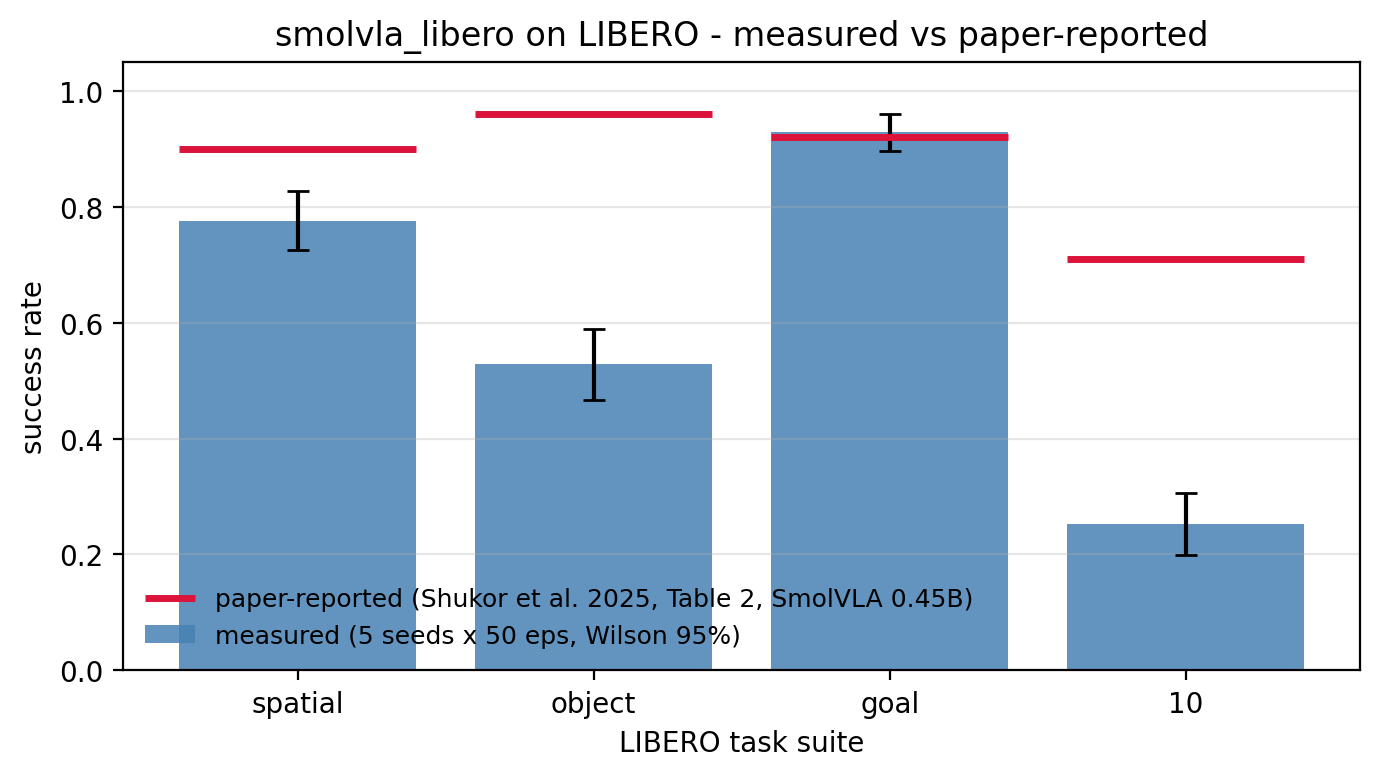

  libero_spatial      measured=0.776 +/- 0.051   paper=0.900   gap=-0.124
  libero_object       measured=0.528 +/- 0.061   paper=0.960   gap=-0.432
  libero_goal         measured=0.928 +/- 0.032   paper=0.920   gap=+0.008
  libero_10           measured=0.252 +/- 0.054   paper=0.710   gap=-0.458


In [8]:
# Cell 7b - smolvla LIBERO breakdown bar chart
# One bar per LIBERO task suite (spatial, object, goal, 10); error bars are
# Wilson 95% half-widths. Horizontal dashes mark the smolvla paper-reported
# success rates from policies.yaml so the gap is visually obvious.

LIBERO_TASK_ORDER = ('libero_spatial', 'libero_object', 'libero_goal', 'libero_10')

smol = breakdown[breakdown['policy'] == 'smolvla_libero'].set_index('env').reindex(LIBERO_TASK_ORDER)
smol_paper = PAPER_REPORTED.get('smolvla_libero', {})

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(LIBERO_TASK_ORDER))
bars = ax.bar(x, smol['success_rate'], yerr=smol['wilson_hw'], capsize=4, color='steelblue', alpha=0.85, label='measured (5 seeds x 50 eps, Wilson 95%)')

for i, env in enumerate(LIBERO_TASK_ORDER):
    if env in smol_paper:
        ax.hlines(smol_paper[env], i - 0.4, i + 0.4, colors='crimson', linewidth=2.5)

ax.hlines([], [], [], colors='crimson', linewidth=2.5, label='paper-reported (Shukor et al. 2025, Table 2, SmolVLA 0.45B)')

ax.set_xticks(x)
ax.set_xticklabels([env.replace('libero_', '') for env in LIBERO_TASK_ORDER])
ax.set_ylim(0, 1.05)
ax.set_ylabel('success rate')
ax.set_xlabel('LIBERO task suite')
ax.set_title('smolvla_libero on LIBERO - measured vs paper-reported')
ax.legend(loc='lower left', fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()

ASSETS_DIR = REPO_ROOT / 'docs' / 'assets'
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(ASSETS_DIR / 'fig-smolvla-libero.svg', bbox_inches='tight', dpi=120, transparent=True)
fig.savefig(ASSETS_DIR / 'fig-smolvla-libero.png', bbox_inches='tight', dpi=200, facecolor='white')
plt.show()

for env in LIBERO_TASK_ORDER:
    measured = smol.loc[env, 'success_rate']
    hw = smol.loc[env, 'wilson_hw']
    paper = smol_paper.get(env, float('nan'))
    gap = measured - paper
    print(f'  {env:18s}  measured={measured:.3f} +/- {hw:.3f}   paper={paper:.3f}   gap={gap:+.3f}')

In [9]:
# Cell 8 - diffusion_policy x pusht single stat
# Only non-LIBERO policy that hit non-baseline success in v1. Wilson CI plus
# pivotal bootstrap CI for the Methods table.

dp = df[(df['policy'] == 'diffusion_policy') & (df['env'] == 'pusht')]
dp_n = len(dp)
dp_k = int(dp['success'].sum())
dp_rate = dp_k / dp_n
dp_wlo, dp_whi = wilson_ci(dp_k, dp_n, ci=CI)
dp_blo, dp_bhi = bootstrap_pivotal_ci(
    dp['success'].to_numpy().astype(bool),
    alpha=ALPHA,
    n_resamples=N_RESAMPLES,
    seed=BOOTSTRAP_SEED,
)
dp_paper = PAPER_REPORTED['diffusion_policy']['pusht']
print('diffusion_policy x pusht (only non-LIBERO policy above baseline in v1):')
print(f'  n_episodes        : {dp_n}')
print(f'  n_successes       : {dp_k}')
print(f'  success rate      : {dp_rate:.3f}')
print(f'  Wilson 95% CI     : [{dp_wlo:.3f}, {dp_whi:.3f}]   (half-width {(dp_whi - dp_wlo) / 2:.3f})')
print(f'  pivotal boot 95%  : [{dp_blo:.3f}, {dp_bhi:.3f}]   (n_resamples={N_RESAMPLES}, seed={BOOTSTRAP_SEED})')
print(f'  paper-reported    : {dp_paper:.3f}   (LeRobot Hub card, 500 eps, binary success)')
print(f'  measured - paper  : {dp_rate - dp_paper:+.3f}')

diffusion_policy x pusht (only non-LIBERO policy above baseline in v1):
  n_episodes        : 125
  n_successes       : 102
  success rate      : 0.816
  Wilson 95% CI     : [0.739, 0.874]   (half-width 0.068)
  pivotal boot 95%  : [0.752, 0.888]   (n_resamples=10000, seed=42)
  paper-reported    : 0.654   (LeRobot Hub card, 500 eps, binary success)
  measured - paper  : +0.162


In [10]:
# Cell 9 - Baseline sanity
# no_op should be flat 0.0 everywhere. random should be at floor on all envs
# except aloha_transfer_cube where the success heuristic is permissive
# enough that a uniform-action policy occasionally trips it.

baselines = breakdown[breakdown['policy'].isin(['no_op', 'random'])].sort_values(['policy', 'env']).reset_index(drop=True)
show = baselines[['policy', 'env', 'n_episodes', 'success_rate', 'wilson_lo', 'wilson_hi']]
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_rows', None):
    print(show.to_string(index=False))

noop = baselines[baselines['policy'] == 'no_op']
noop_zero = bool((noop['success_rate'] == 0).all())
rand_nonzero = baselines[(baselines['policy'] == 'random') & (baselines['success_rate'] > 0)]

print()
print(f'no_op: all envs at success_rate == 0.0: {noop_zero}')
if len(rand_nonzero):
    print('random: above-zero cells:')
    print(rand_nonzero[['env', 'success_rate', 'wilson_lo', 'wilson_hi']].to_string(index=False))
else:
    print('random: zero on every env')

print()
print('Sanity: baselines behave - no_op is flat 0.0, random spikes only on aloha_transfer_cube (gym-aloha success heuristic is the loosest of the matrix).')

policy                 env  n_episodes  success_rate  wilson_lo  wilson_hi
 no_op aloha_transfer_cube         250        0.0000     0.0000     0.0151
 no_op           libero_10         250        0.0000     0.0000     0.0151
 no_op         libero_goal         250        0.0000     0.0000     0.0151
 no_op       libero_object         250        0.0000     0.0000     0.0151
 no_op      libero_spatial         250        0.0000     0.0000     0.0151
 no_op               pusht         250        0.0000     0.0000     0.0151
random aloha_transfer_cube         250        0.0520     0.0306     0.0869
random           libero_10         250        0.0000     0.0000     0.0151
random         libero_goal         250        0.0000     0.0000     0.0151
random       libero_object         250        0.0000     0.0000     0.0151
random      libero_spatial         250        0.0000     0.0000     0.0151
random               pusht         250        0.0000     0.0000     0.0151

no_op: all envs at succe

In [11]:
# Cell 10 - Anomaly callout
# Flag (policy, env) cells where measured success rate is < 50% of the
# paper-reported number. Pre-rerun-merge this surfaces the xvla cells (all
# zero due to the postprocessor bug fixed in PR #71); post-rerun this list
# should be small.

anomaly_rows = []
for policy, mapping in PAPER_REPORTED.items():
    for env, paper in mapping.items():
        cell = breakdown[(breakdown['policy'] == policy) & (breakdown['env'] == env)]
        if len(cell) == 0:
            continue
        measured = float(cell['success_rate'].iloc[0])
        if measured < 0.5 * paper:
            anomaly_rows.append({
                'policy': policy,
                'env': env,
                'measured': measured,
                'paper': paper,
                'ratio': measured / paper if paper > 0 else float('nan'),
                'glyph': cell['glyph'].iloc[0] or '',
            })

anomalies = pd.DataFrame(anomaly_rows)
if len(anomalies) == 0:
    print('No (policy, env) cell falls below 50% of its paper-reported success.')
else:
    print('Cells measured below 50% of paper-reported:')
    with pd.option_context('display.float_format', '{:.3f}'.format):
        print(anomalies.to_string(index=False))
    print()
    print('Pre-rerun-merge note: xvla_libero rows are expected here (postprocessor bug, fixed in PR #71; re-run queued as task #91). After the xvla re-run lands, this list should be short.')

Cells measured below 50% of paper-reported:
        policy            env  measured  paper  ratio glyph
   xvla_libero libero_spatial     0.000  0.982  0.000      
   xvla_libero  libero_object     0.000  0.986  0.000      
   xvla_libero    libero_goal     0.000  0.978  0.000      
   xvla_libero      libero_10     0.000  0.976  0.000      
smolvla_libero      libero_10     0.252  0.710  0.355      

Pre-rerun-merge note: xvla_libero rows are expected here (postprocessor bug, fixed in PR #71; re-run queued as task #91). After the xvla re-run lands, this list should be short.


In [12]:
# Cell 11 - Stats-rigor block
# For every headline-quality cell, report:
#   - n_episodes (flat episode count)
#   - seed-level mean success and sample variance across the 5 seed means
#   - Wilson 95% CI on the pooled rate
#   - pivotal bootstrap 95% CI on the pooled rate (n_resamples=10000, seed=42)
#   - reconciliation flag: True iff |Wilson half-width - bootstrap half-width|
#     exceeds the Wilson half-width itself (i.e. the two CIs disagree by more
#     than a Wilson HW)
#
# Bootstrap math is deferred to lerobot_bench.stats.bootstrap_pivotal_ci -
# the notebook does not roll its own resampler.

rigor_rows = []
for (policy, env), cell in df.groupby(['policy', 'env'], sort=False):
    outcomes = cell['success'].to_numpy().astype(bool)
    n = outcomes.size
    k = int(outcomes.sum())
    rate = k / n

    seed_means = cell.groupby('seed')['success'].mean().to_numpy()
    seed_var = float(seed_means.var(ddof=1)) if seed_means.size > 1 else 0.0

    wlo, whi = wilson_ci(k, n, ci=CI)
    blo, bhi = bootstrap_pivotal_ci(outcomes, alpha=ALPHA, n_resamples=N_RESAMPLES, seed=BOOTSTRAP_SEED)

    w_hw = (whi - wlo) / 2.0
    b_hw = (bhi - blo) / 2.0
    disagrees = abs(w_hw - b_hw) > w_hw

    rigor_rows.append({
        'policy': policy,
        'env': env,
        'n_episodes': n,
        'success_rate': rate,
        'seed_mean_var': seed_var,
        'wilson_lo': wlo,
        'wilson_hi': whi,
        'wilson_hw': w_hw,
        'boot_lo': blo,
        'boot_hi': bhi,
        'boot_hw': b_hw,
        'ci_disagree': disagrees,
    })

rigor = pd.DataFrame(rigor_rows).sort_values(['policy', 'env'], ignore_index=True)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_rows', None):
    print(rigor.to_string(index=False))

disagreeing = rigor[rigor['ci_disagree']]
print()
if len(disagreeing) == 0:
    print('Wilson and pivotal bootstrap CIs agree (half-widths within one Wilson HW of each other) on every cell.')
else:
    print(f'CI disagreement on {len(disagreeing)} cell(s) - expected at saturation (rate near 0 or 1) where Wilson asymmetry > bootstrap symmetric pivotal:')
    print(disagreeing[['policy', 'env', 'success_rate', 'wilson_hw', 'boot_hw']].to_string(index=False))

          policy                 env  n_episodes  success_rate  seed_mean_var  wilson_lo  wilson_hi  wilson_hw  boot_lo  boot_hi  boot_hw  ci_disagree
             act aloha_transfer_cube         250        0.8240         0.0059     0.7720     0.8662     0.0471   0.7800   0.8720   0.0460        False
diffusion_policy               pusht         125        0.8160         0.0045     0.7390     0.8741     0.0676   0.7520   0.8880   0.0680        False
           no_op aloha_transfer_cube         250        0.0000         0.0000     0.0000     0.0151     0.0076   0.0000   0.0000   0.0000        False
           no_op           libero_10         250        0.0000         0.0000     0.0000     0.0151     0.0076   0.0000   0.0000   0.0000        False
           no_op         libero_goal         250        0.0000         0.0000     0.0000     0.0151     0.0076   0.0000   0.0000   0.0000        False
           no_op       libero_object         250        0.0000         0.0000     0.0000     0

In [13]:
# Cell 12 - Reproducibility footer
# Every coordinate a reader needs to re-derive the numbers above.


def _git_sha(root: Path) -> str:
    try:
        return subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True, timeout=5).strip()
    except (OSError, subprocess.SubprocessError):
        return 'unknown'


print('Reproducibility footer')
print('=' * 60)
print(f'lerobot_bench.__version__   : {lerobot_bench.__version__}')
print(f'git rev-parse HEAD          : {_git_sha(REPO_ROOT)}')
print(f'sweep dir                   : {SWEEP_DIR}')
print(f'base parquet                : {BASE_PARQUET.name}')
print(f'rerun parquets loaded       : {[p.name for p in (ACT_RERUN_PARQUET, XVLA_RERUN_PARQUET) if p.exists()]}')
print(f'rerun parquets missing      : {[p.name for p in (ACT_RERUN_PARQUET, XVLA_RERUN_PARQUET) if not p.exists()]}')
print(f'total merged rows           : {len(df):,}')
print(f'unique (policy, env, seed)  : {df.groupby(["policy", "env", "seed"]).ngroups}')
print(f'lerobot_version (parquet)   : {sorted(df.lerobot_version.unique())}')
print(f'distinct code_sha values    : {df.code_sha.nunique()}')
print(f'bootstrap n_resamples       : {N_RESAMPLES:,}')
print(f'bootstrap seed              : {BOOTSTRAP_SEED}')
print(f'CI level                    : {CI}')
print(f'python                      : {sys.version.split()[0]}')
print(f'numpy / pandas / matplotlib : {np.__version__} / {pd.__version__} / {plt.matplotlib.__version__}')

Reproducibility footer
lerobot_bench.__version__   : 0.0.1
git rev-parse HEAD          : d36e8bd380abbdd35a1ac983304b7b1fd70ad4d6
sweep dir                   : results/sweep-full
base parquet                : results.parquet
rerun parquets loaded       : ['results-act-rerun.parquet']
rerun parquets missing      : ['results-xvla-rerun.parquet']
total merged rows           : 5,250
unique (policy, env, seed)  : 110
lerobot_version (parquet)   : ['0.5.1']
distinct code_sha values    : 13
bootstrap n_resamples       : 10,000
bootstrap seed              : 42
CI level                    : 0.95
python                      : 3.12.12
numpy / pandas / matplotlib : 2.2.6 / 2.3.3 / 3.10.8
